<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/RESSON%C3%82NCIA_MLPRegressor_BLOCO3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Treinamento,Neurônios,Ativação,Perda Final,Número de Épocas,Ranking (1=melhor)
0,T5,10,relu,0.000613,65,1
1,T8,15,relu,0.000855,53,2
2,T7,15,tanh,0.001224,29,3
3,T1,5,tanh,0.001755,133,4
4,T9,15,logistic,0.016983,18,5
5,T6,10,logistic,0.020071,21,6
6,T2,5,relu,0.020925,75,7
7,T3,5,logistic,0.021387,35,8
8,T4,10,tanh,0.034849,22,9


Melhor config: neurônios=10, ativação=relu
Perda Final: 0.0006131769683741762
Épocas: 65


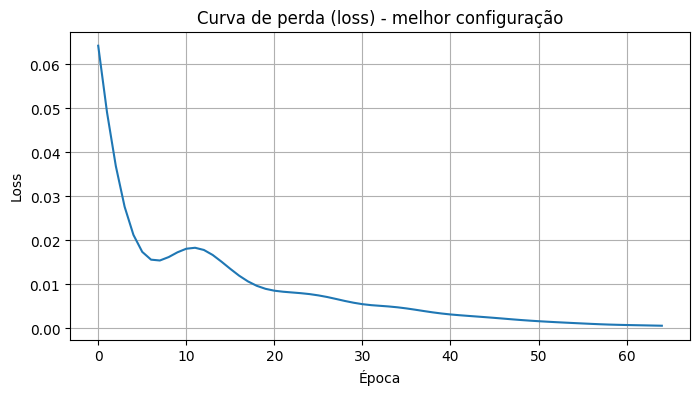

MAE : 0.027278
MSE : 0.001085
RMSE: 0.032944
MAPE: 5.117%


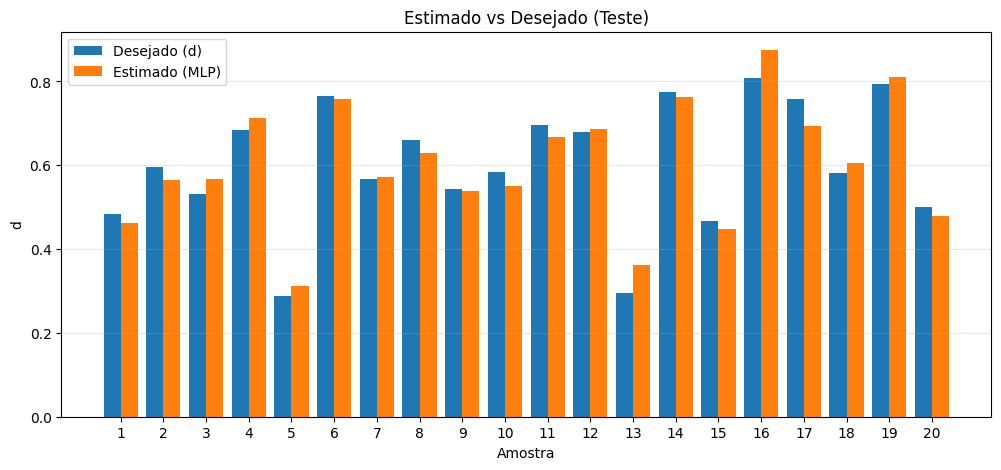

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_train = pd.read_csv("/content/ressonanciaMLP.csv")
df_test  = pd.read_csv("/content/ressonanciaMLPTest.csv")

X_train = df_train[["x1", "x2", "x3"]].astype(float)
y_train = df_train["d"].astype(float)

X_test  = df_test[["x1", "x2", "x3"]].astype(float)
y_test  = df_test["d"].astype(float)

def mape(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def train_mlp(hidden_neurons, activation, X, y, random_state=42):
    mlp = MLPRegressor(
        hidden_layer_sizes=(hidden_neurons,),
        activation=activation,
        learning_rate_init=0.01,
        max_iter=1000,
        random_state=random_state
    )
    mlp.fit(X, y)
    loss_curve = getattr(mlp, "loss_curve_", None)
    return mlp, loss_curve

activations = ["tanh", "relu", "logistic"]
neurons_list = [5, 10, 15]

results = []
models = {}
t = 1

for n in neurons_list:
    for act in activations:
        model, loss_curve = train_mlp(n, act, X_train, y_train, random_state=42)
        results.append({
            "Treinamento": f"T{t}",
            "Neurônios": n,
            "Ativação": act,
            "Perda Final": float(model.loss_),
            "Número de Épocas": int(model.n_iter_)
        })
        models[(n, act)] = {"model": model, "loss_curve": loss_curve}
        t += 1

df_results = pd.DataFrame(results)
df_results["Ranking (1=melhor)"] = df_results["Perda Final"].rank(method="dense", ascending=True).astype(int)
df_results = df_results.sort_values(["Ranking (1=melhor)", "Perda Final"]).reset_index(drop=True)
display(df_results)

best_row = df_results.iloc[0]
best_n = int(best_row["Neurônios"])
best_act = str(best_row["Ativação"])

best_model = models[(best_n, best_act)]["model"]
best_loss_curve = models[(best_n, best_act)]["loss_curve"]

print(f"Melhor config: neurônios={best_n}, ativação={best_act}")
print(f"Perda Final: {best_row['Perda Final']}")
print(f"Épocas: {best_row['Número de Épocas']}")

if best_loss_curve is not None:
    plt.figure(figsize=(8,4))
    plt.plot(best_loss_curve)
    plt.title("Curva de perda (loss) - melhor configuração")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

y_pred_test = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mape_val = mape(y_test, y_pred_test)

print(f"MAE : {mae:.6f}")
print(f"MSE : {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAPE: {mape_val:.3f}%")

idx = np.arange(len(y_test))
width = 0.40

plt.figure(figsize=(12,5))
plt.bar(idx - width/2, y_test.values, width, label="Desejado (d)")
plt.bar(idx + width/2, y_pred_test, width, label="Estimado (MLP)")
plt.title("Estimado vs Desejado (Teste)")
plt.xlabel("Amostra")
plt.ylabel("d")
plt.xticks(idx, [str(i+1) for i in idx])
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()